# Deep Learning Showcase: See Neural Networks in Action

---

This notebook demonstrates **three powerful deep learning techniques** using PyTorch and the MNIST handwritten digit dataset. Each section builds on the last, showing progressively more impressive capabilities:

| # | Technique | What It Does |
|---|-----------|-------------|
| 1 | **Autoencoder** | Compresses images to 25% of their size and reconstructs them |
| 2 | **Denoising Autoencoder** | Removes heavy noise from corrupted images |
| 3 | **GAN (Generative Adversarial Network)** | Generates brand-new handwritten digits from scratch |

> **Requirements:** PyTorch, torchvision, numpy, matplotlib (runs on CPU, no GPU needed)  
> **Runtime:** ~10-15 minutes total

---

## Setup & Data Loading

We use the **MNIST dataset** — 70,000 grayscale images of handwritten digits (0-9), each 28x28 pixels. It downloads automatically.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from torchvision import datasets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import clear_output

%matplotlib inline
plt.rcParams['figure.facecolor'] = '#f8f9fa'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['font.size'] = 11

# Load MNIST
transform = transforms.ToTensor()
train_data = datasets.MNIST(root='data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='data', train=False, download=True, transform=transform)

batch_size = 64
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False)

print(f'Training samples: {len(train_data):,}')
print(f'Test samples:     {len(test_data):,}')
print(f'Image shape:      {train_data[0][0].shape}')

0.3%

0.7%

1.0%

1.3%

1.7%

...

97.4%

99.4%

100.0%

100.0%

Training samples: 60,000
Test samples:     10,000
Image shape:      torch.Size([1, 28, 28])


### A Peek at the Data

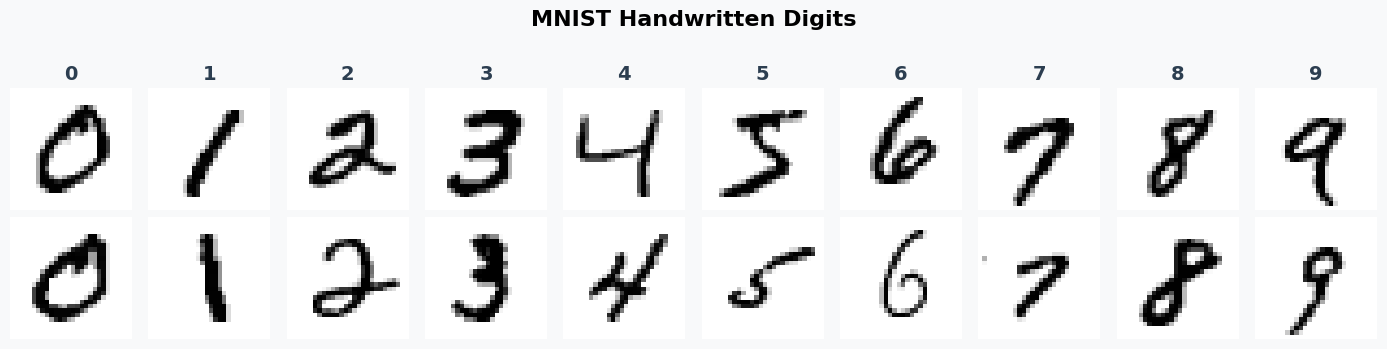

In [2]:
fig, axes = plt.subplots(2, 10, figsize=(14, 3.5))
fig.suptitle('MNIST Handwritten Digits', fontsize=16, fontweight='bold', y=1.02)

for digit in range(10):
    # Find two examples of each digit
    idxs = [i for i, (_, label) in enumerate(train_data) if label == digit]
    for row in range(2):
        img = train_data[idxs[row]][0].squeeze().numpy()
        axes[row, digit].imshow(img, cmap='gray_r')
        axes[row, digit].axis('off')
        if row == 0:
            axes[row, digit].set_title(str(digit), fontsize=14, fontweight='bold', color='#2c3e50')

plt.tight_layout()
plt.show()

---

# Part 1: Convolutional Autoencoder

An autoencoder learns to **compress** an image into a tiny representation, then **reconstruct** it back. Think of it like a neural network that learns extreme JPEG compression.

```
28x28 image (784 values)  -->  [Encoder]  -->  7x7x4 (196 values)  -->  [Decoder]  -->  28x28 image
                                               only 25% of original!
```

The network is forced through a **bottleneck**, so it must learn what features are truly important.

In [3]:
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super(ConvAutoencoder, self).__init__()
        # -- Encoder: compress 28x28 --> 7x7x4 --
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)   # 28x28x1  -> 28x28x16
        self.conv2 = nn.Conv2d(16, 4, 3, padding=1)    # 14x14x16 -> 14x14x4
        self.pool = nn.MaxPool2d(2, 2)                 # halves spatial dims
        
        # -- Decoder: expand 7x7x4 --> 28x28x1 --
        self.t_conv1 = nn.ConvTranspose2d(4, 16, 2, stride=2)  # 7x7x4  -> 14x14x16
        self.t_conv2 = nn.ConvTranspose2d(16, 1, 2, stride=2)  # 14x14x16 -> 28x28x1

    def forward(self, x):
        # Encode
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))  # bottleneck
        # Decode
        x = F.relu(self.t_conv1(x))
        x = torch.sigmoid(self.t_conv2(x))
        return x

ae_model = ConvAutoencoder()
print(ae_model)
total_params = sum(p.numel() for p in ae_model.parameters())
print(f'\nTotal parameters: {total_params:,}')

ConvAutoencoder(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (t_conv1): ConvTranspose2d(4, 16, kernel_size=(2, 2), stride=(2, 2))
  (t_conv2): ConvTranspose2d(16, 1, kernel_size=(2, 2), stride=(2, 2))
)

Total parameters: 1,077


In [4]:
# Train the Autoencoder
criterion = nn.MSELoss()
optimizer = optim.Adam(ae_model.parameters(), lr=0.001)
n_epochs = 15
ae_losses = []

print('Training Autoencoder...')
print('-' * 45)
for epoch in range(1, n_epochs + 1):
    train_loss = 0.0
    for images, _ in train_loader:
        optimizer.zero_grad()
        outputs = ae_model(images)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
    avg_loss = train_loss / len(train_loader.dataset)
    ae_losses.append(avg_loss)
    bar = '#' * int(30 * epoch / n_epochs)
    print(f'  Epoch {epoch:2d}/{n_epochs}  [{bar:<30}]  Loss: {avg_loss:.6f}')

print('\nDone!')

Training Autoencoder...
---------------------------------------------


  Epoch  1/15  [##                            ]  Loss: 0.042477


  Epoch  2/15  [####                          ]  Loss: 0.016312


  Epoch  3/15  [######                        ]  Loss: 0.015037


  Epoch  4/15  [########                      ]  Loss: 0.014299


...

  Epoch 11/15  [######################        ]  Loss: 0.009488


  Epoch 12/15  [########################      ]  Loss: 0.009305


  Epoch 13/15  [##########################    ]  Loss: 0.009172


  Epoch 14/15  [############################  ]  Loss: 0.009063


  Epoch 15/15  [##############################]  Loss: 0.008979

Done!


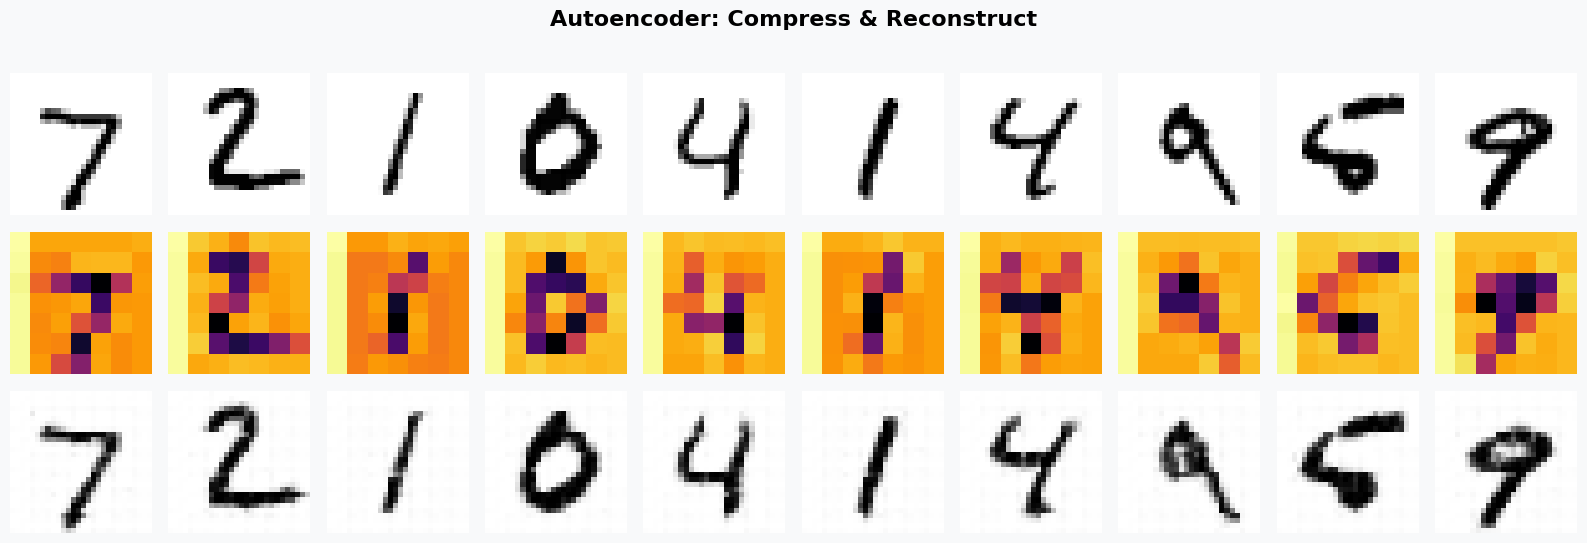

In [5]:
# Visualize Autoencoder Results
ae_model.eval()
dataiter = iter(test_loader)
images, labels = next(dataiter)
output = ae_model(images).detach().numpy()
images_np = images.numpy()

n_show = 10
fig, axes = plt.subplots(3, n_show, figsize=(16, 5.5))
fig.suptitle('Autoencoder: Compress & Reconstruct', fontsize=16, fontweight='bold', y=1.0)

for i in range(n_show):
    # Original
    axes[0, i].imshow(np.squeeze(images_np[i]), cmap='gray_r')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('Original', fontsize=13, fontweight='bold', rotation=0, labelpad=75)
    
    # Compressed representation (just show the 4 channels averaged)
    with torch.no_grad():
        encoded = ae_model.pool(F.relu(ae_model.conv1(images[i:i+1])))
        encoded = ae_model.pool(F.relu(ae_model.conv2(encoded)))
    enc_vis = encoded.squeeze().mean(dim=0).numpy()
    axes[1, i].imshow(enc_vis, cmap='inferno')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('Compressed\n(7x7)', fontsize=13, fontweight='bold', rotation=0, labelpad=75)
    
    # Reconstructed
    axes[2, i].imshow(np.squeeze(output[i]), cmap='gray_r')
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_ylabel('Rebuilt', fontsize=13, fontweight='bold', rotation=0, labelpad=75)

plt.tight_layout()
plt.show()

---

# Part 2: Denoising Autoencoder

What if we **deliberately corrupt** images with noise, then train the network to clean them up? This is a **denoising autoencoder** — it learns to see through the noise and recover the original signal.

```
Clean image + Random noise  -->  [Denoiser Network]  -->  Clean image (recovered!)
```

This has real-world applications in photography, medical imaging, and satellite imagery.

In [6]:
class ConvDenoiser(nn.Module):
    def __init__(self):
        super(ConvDenoiser, self).__init__()
        # Deeper encoder for the harder denoising task
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 16, 3, padding=1)
        self.conv3 = nn.Conv2d(16, 8, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        
        # Decoder with transpose convolutions
        self.t_conv1 = nn.ConvTranspose2d(8, 8, 3, stride=2)
        self.t_conv2 = nn.ConvTranspose2d(8, 16, 2, stride=2)
        self.t_conv3 = nn.ConvTranspose2d(16, 32, 2, stride=2)
        self.conv_out = nn.Conv2d(32, 1, 3, padding=1)

    def forward(self, x):
        # Encode
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        # Decode
        x = F.relu(self.t_conv1(x))
        x = F.relu(self.t_conv2(x))
        x = F.relu(self.t_conv3(x))
        x = torch.sigmoid(self.conv_out(x))
        return x

dn_model = ConvDenoiser()
print(dn_model)
total_params = sum(p.numel() for p in dn_model.parameters())
print(f'\nTotal parameters: {total_params:,}')

ConvDenoiser(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (t_conv1): ConvTranspose2d(8, 8, kernel_size=(3, 3), stride=(2, 2))
  (t_conv2): ConvTranspose2d(8, 16, kernel_size=(2, 2), stride=(2, 2))
  (t_conv3): ConvTranspose2d(16, 32, kernel_size=(2, 2), stride=(2, 2))
  (conv_out): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)

Total parameters: 9,585


In [7]:
# Train the Denoiser
criterion = nn.MSELoss()
optimizer = optim.Adam(dn_model.parameters(), lr=0.001)
n_epochs = 15
noise_factor = 0.5
dn_losses = []

print('Training Denoising Autoencoder...')
print('-' * 45)
for epoch in range(1, n_epochs + 1):
    train_loss = 0.0
    for images, _ in train_loader:
        # Add Gaussian noise
        noisy_imgs = images + noise_factor * torch.randn_like(images)
        noisy_imgs = torch.clamp(noisy_imgs, 0., 1.)
        
        optimizer.zero_grad()
        outputs = dn_model(noisy_imgs)
        loss = criterion(outputs, images)  # compare to CLEAN images
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
    avg_loss = train_loss / len(train_loader.dataset)
    dn_losses.append(avg_loss)
    bar = '#' * int(30 * epoch / n_epochs)
    print(f'  Epoch {epoch:2d}/{n_epochs}  [{bar:<30}]  Loss: {avg_loss:.6f}')

print('\nDone!')

Training Denoising Autoencoder...
---------------------------------------------


  Epoch  1/15  [##                            ]  Loss: 0.067236


  Epoch  2/15  [####                          ]  Loss: 0.047248


  Epoch  3/15  [######                        ]  Loss: 0.044663


  Epoch  4/15  [########                      ]  Loss: 0.043214


...

  Epoch 11/15  [######################        ]  Loss: 0.037759


  Epoch 12/15  [########################      ]  Loss: 0.037201


  Epoch 13/15  [##########################    ]  Loss: 0.036745


  Epoch 14/15  [############################  ]  Loss: 0.036363


  Epoch 15/15  [##############################]  Loss: 0.036047

Done!


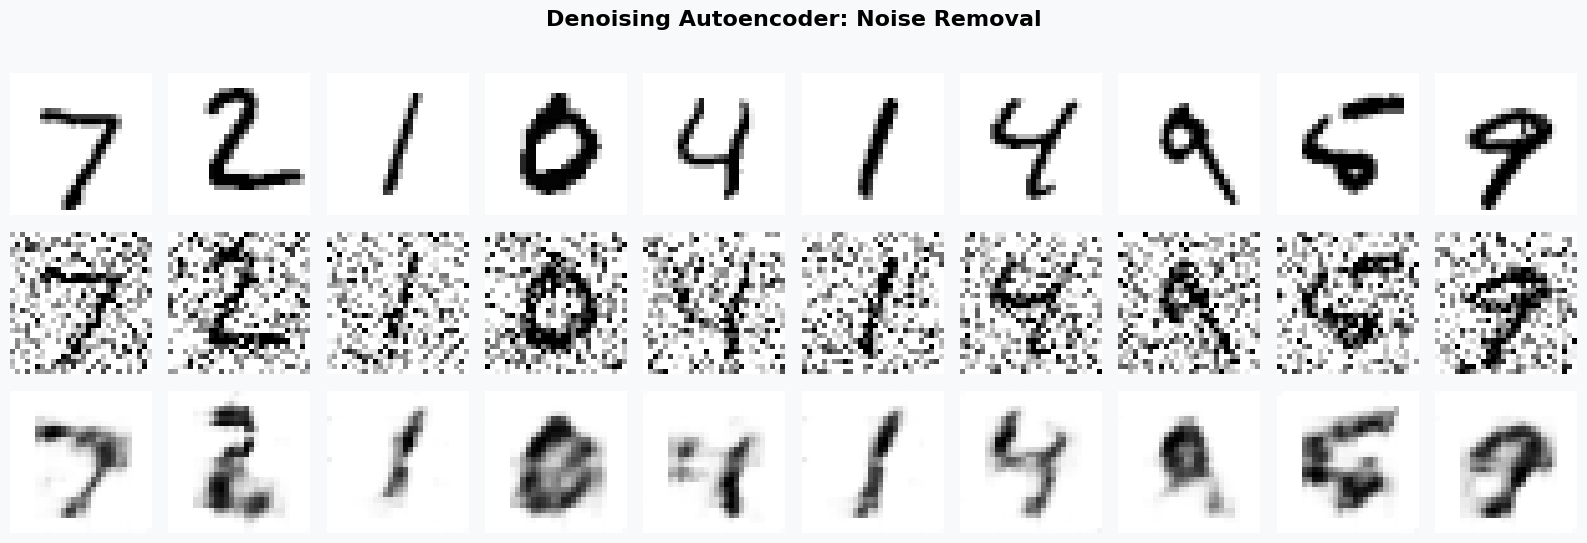

In [8]:
# Visualize Denoising Results
dn_model.eval()
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Create noisy versions
noisy_imgs = images + noise_factor * torch.randn_like(images)
noisy_imgs = torch.clamp(noisy_imgs, 0., 1.)

# Denoise
with torch.no_grad():
    denoised = dn_model(noisy_imgs)

n_show = 10
fig, axes = plt.subplots(3, n_show, figsize=(16, 5.5))
fig.suptitle('Denoising Autoencoder: Noise Removal', fontsize=16, fontweight='bold', y=1.0)

row_labels = ['Original', 'Noisy\nInput', 'Denoised\nOutput']
row_data = [images.numpy(), noisy_imgs.numpy(), denoised.numpy()]

for row_idx, (label, data) in enumerate(zip(row_labels, row_data)):
    for i in range(n_show):
        axes[row_idx, i].imshow(np.squeeze(data[i]), cmap='gray_r')
        axes[row_idx, i].axis('off')
        if i == 0:
            axes[row_idx, i].set_ylabel(label, fontsize=13, fontweight='bold', rotation=0, labelpad=75)

plt.tight_layout()
plt.show()

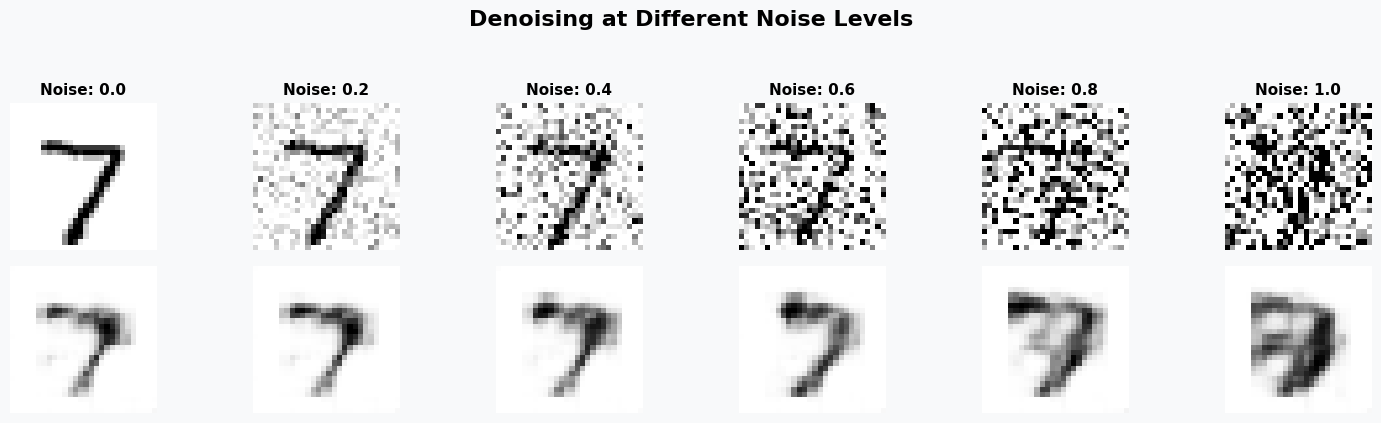

In [9]:
# Show multiple noise levels
dn_model.eval()
sample_img = images[0:1]  # Pick one digit

noise_levels = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
fig, axes = plt.subplots(2, len(noise_levels), figsize=(15, 4))
fig.suptitle('Denoising at Different Noise Levels', fontsize=16, fontweight='bold', y=1.05)

for j, nf in enumerate(noise_levels):
    noisy = sample_img + nf * torch.randn_like(sample_img)
    noisy = torch.clamp(noisy, 0., 1.)
    with torch.no_grad():
        cleaned = dn_model(noisy)
    
    axes[0, j].imshow(np.squeeze(noisy.numpy()), cmap='gray_r')
    axes[0, j].axis('off')
    axes[0, j].set_title(f'Noise: {nf:.1f}', fontsize=11, fontweight='bold')
    
    axes[1, j].imshow(np.squeeze(cleaned.numpy()), cmap='gray_r')
    axes[1, j].axis('off')

axes[0, 0].set_ylabel('Input', fontsize=13, fontweight='bold', rotation=0, labelpad=50)
axes[1, 0].set_ylabel('Output', fontsize=13, fontweight='bold', rotation=0, labelpad=50)
plt.tight_layout()
plt.show()

---

# Part 3: GAN — Generate New Digits from Scratch

A **Generative Adversarial Network** is like an art forger vs. a detective:

- **Generator (Forger):** Takes random noise and tries to create convincing fake digits
- **Discriminator (Detective):** Tries to tell real digits from fakes

They compete, and both get better. Eventually the Generator produces digits so realistic that the Discriminator can't tell the difference.

```
Random noise (100 values)  -->  [Generator]  -->  Fake 28x28 image
                                                      |
Real 28x28 image  ------>  [Discriminator]  <---------+
                                  |
                           Real or Fake?
```

In [10]:
class Discriminator(nn.Module):
    def __init__(self, input_size, hidden_dim):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_dim * 4)
        self.fc2 = nn.Linear(hidden_dim * 4, hidden_dim * 2)
        self.fc3 = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = self.dropout(F.leaky_relu(self.fc1(x), 0.2))
        x = self.dropout(F.leaky_relu(self.fc2(x), 0.2))
        x = self.dropout(F.leaky_relu(self.fc3(x), 0.2))
        return self.fc4(x)


class Generator(nn.Module):
    def __init__(self, input_size, hidden_dim, output_size):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim * 2)
        self.fc3 = nn.Linear(hidden_dim * 2, hidden_dim * 4)
        self.fc4 = nn.Linear(hidden_dim * 4, output_size)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.dropout(F.leaky_relu(self.fc1(x), 0.2))
        x = self.dropout(F.leaky_relu(self.fc2(x), 0.2))
        x = self.dropout(F.leaky_relu(self.fc3(x), 0.2))
        return torch.tanh(self.fc4(x))


# Hyperparameters
z_size = 100          # noise vector size
g_hidden = 32
d_hidden = 32

D = Discriminator(784, d_hidden)
G = Generator(z_size, g_hidden, 784)

print('=== Discriminator ===')
print(D)
print(f'Parameters: {sum(p.numel() for p in D.parameters()):,}')
print()
print('=== Generator ===')
print(G)
print(f'Parameters: {sum(p.numel() for p in G.parameters()):,}')

=== Discriminator ===
Discriminator(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (fc4): Linear(in_features=32, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)
Parameters: 110,849

=== Generator ===
Generator(
  (fc1): Linear(in_features=100, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=128, bias=True)
  (fc4): Linear(in_features=128, out_features=784, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)
Parameters: 114,800


In [11]:
# Loss functions
def real_loss(D_out, smooth=False):
    labels = torch.ones(D_out.size(0)) * (0.9 if smooth else 1.0)
    return nn.BCEWithLogitsLoss()(D_out.squeeze(), labels)

def fake_loss(D_out):
    labels = torch.zeros(D_out.size(0))
    return nn.BCEWithLogitsLoss()(D_out.squeeze(), labels)

# Optimizers
lr = 0.002
d_optimizer = optim.Adam(D.parameters(), lr)
g_optimizer = optim.Adam(G.parameters(), lr)

In [12]:
# Train the GAN
num_epochs = 50
sample_size = 16
fixed_z = torch.from_numpy(np.random.uniform(-1, 1, size=(sample_size, z_size))).float()

samples = []
d_losses = []
g_losses = []

D.train()
G.train()

print('Training GAN...')
print('-' * 55)

for epoch in range(1, num_epochs + 1):
    d_epoch_loss = 0
    g_epoch_loss = 0
    n_batches = 0
    
    for real_images, _ in train_loader:
        bs = real_images.size(0)
        real_images = real_images * 2 - 1  # rescale to [-1, 1]
        
        # --- Train Discriminator ---
        d_optimizer.zero_grad()
        d_real = real_loss(D(real_images), smooth=True)
        z = torch.from_numpy(np.random.uniform(-1, 1, size=(bs, z_size))).float()
        d_fake = fake_loss(D(G(z).detach()))
        d_loss = d_real + d_fake
        d_loss.backward()
        d_optimizer.step()
        
        # --- Train Generator ---
        g_optimizer.zero_grad()
        z = torch.from_numpy(np.random.uniform(-1, 1, size=(bs, z_size))).float()
        g_loss = real_loss(D(G(z)))  # flipped labels
        g_loss.backward()
        g_optimizer.step()
        
        d_epoch_loss += d_loss.item()
        g_epoch_loss += g_loss.item()
        n_batches += 1
    
    d_losses.append(d_epoch_loss / n_batches)
    g_losses.append(g_epoch_loss / n_batches)
    
    # Save samples
    G.eval()
    with torch.no_grad():
        samples.append(G(fixed_z))
    G.train()
    
    if epoch % 5 == 0 or epoch == 1:
        bar = '#' * int(30 * epoch / num_epochs)
        print(f'  Epoch {epoch:3d}/{num_epochs}  [{bar:<30}]  D_loss: {d_losses[-1]:.4f}  G_loss: {g_losses[-1]:.4f}')

print('\nDone!')

Training GAN...
-------------------------------------------------------


  Epoch   1/50  [                              ]  D_loss: 1.0109  G_loss: 2.7869


  Epoch   5/50  [###                           ]  D_loss: 1.1290  G_loss: 1.3871


  Epoch  10/50  [######                        ]  D_loss: 1.1967  G_loss: 1.2576


  Epoch  15/50  [#########                     ]  D_loss: 1.2711  G_loss: 1.1055


...

  Epoch  30/50  [##################            ]  D_loss: 1.2737  G_loss: 1.0567


  Epoch  35/50  [#####################         ]  D_loss: 1.2804  G_loss: 1.0274


  Epoch  40/50  [########################      ]  D_loss: 1.2772  G_loss: 1.0483


  Epoch  45/50  [###########################   ]  D_loss: 1.2829  G_loss: 1.0322


  Epoch  50/50  [##############################]  D_loss: 1.2810  G_loss: 1.0498

Done!


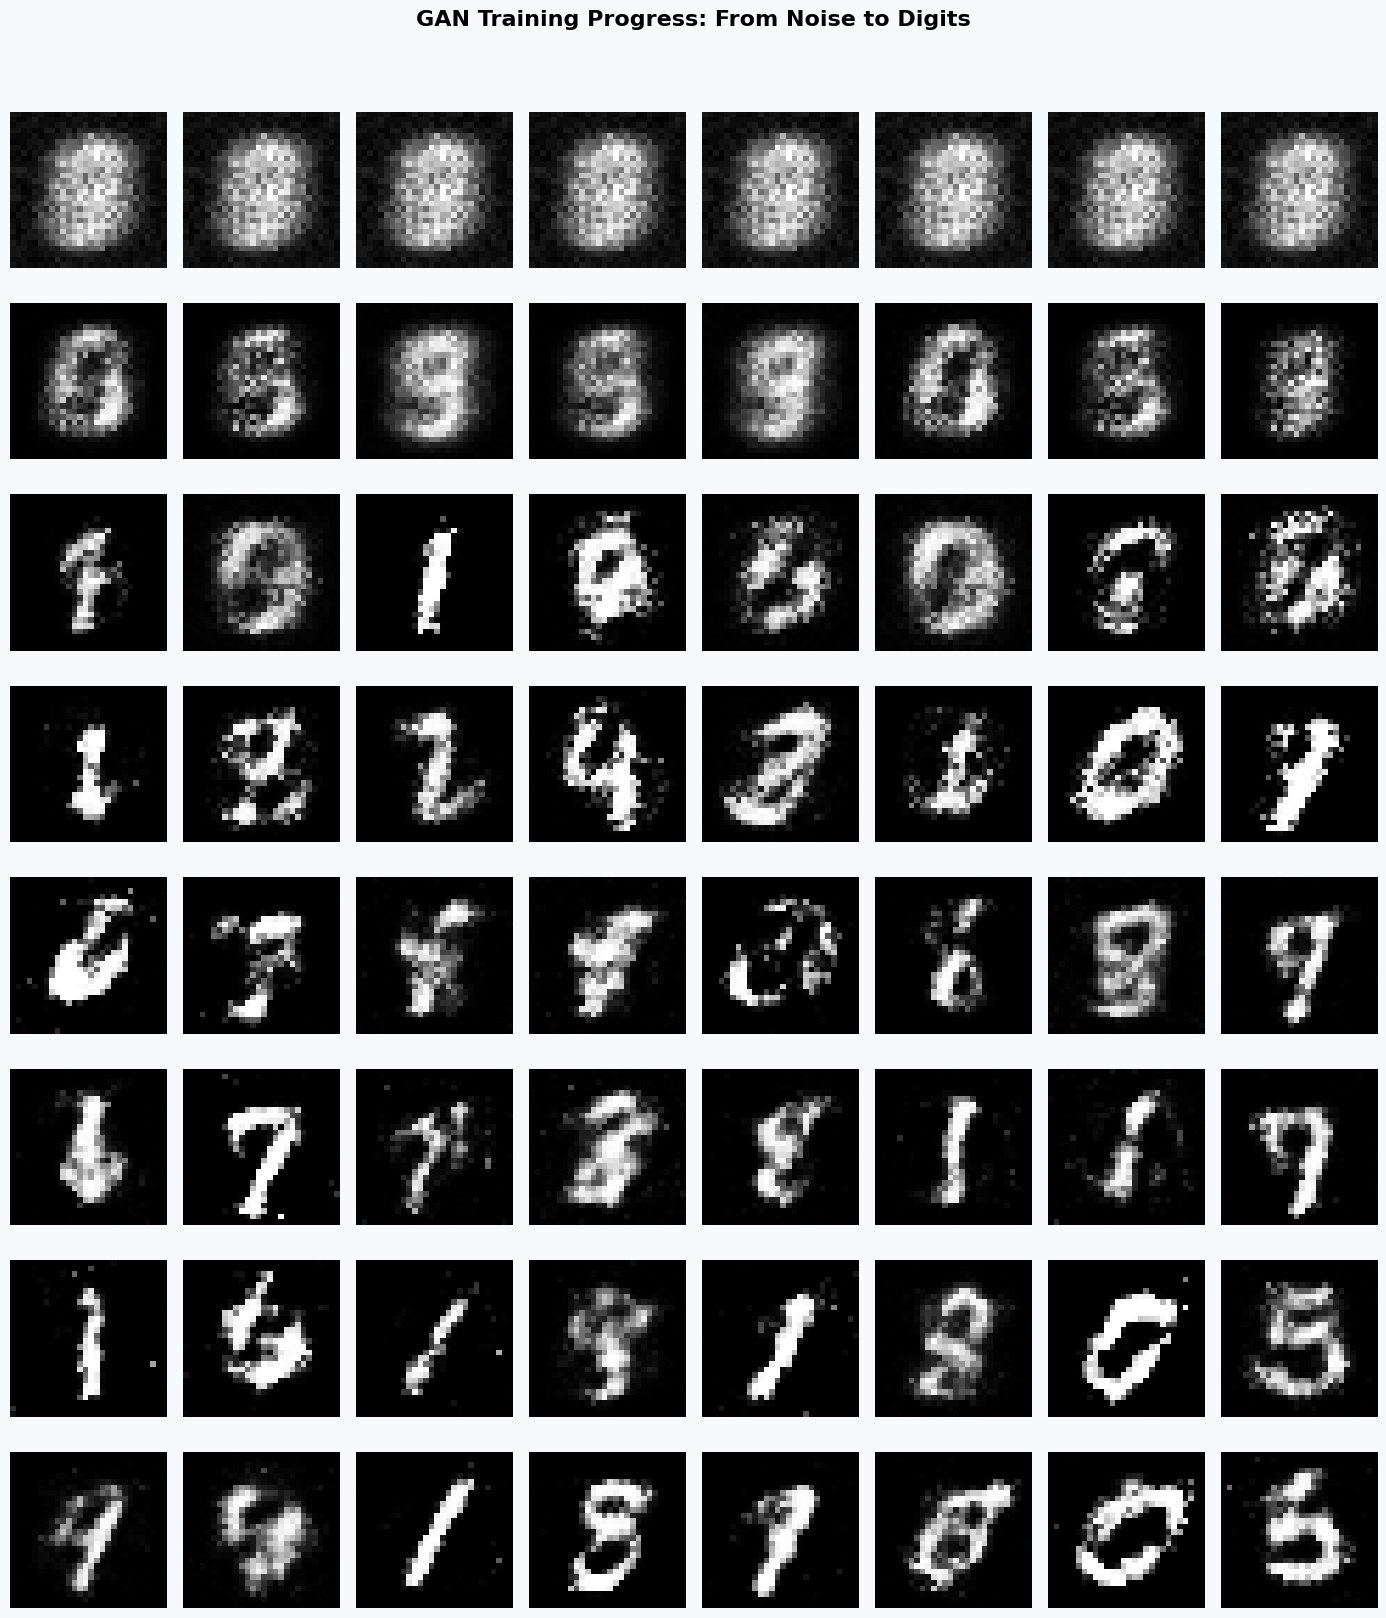

In [13]:
# Visualize how the Generator improved over time
epoch_snapshots = [0, 4, 9, 14, 24, 34, 44, len(samples)-1]
epoch_snapshots = [e for e in epoch_snapshots if e < len(samples)]

n_cols = 8
n_rows = len(epoch_snapshots)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 2.0 * n_rows))
fig.suptitle('GAN Training Progress: From Noise to Digits', fontsize=16, fontweight='bold', y=1.02)

for row, ep in enumerate(epoch_snapshots):
    for col in range(n_cols):
        if col < samples[ep].shape[0]:
            img = samples[ep][col].detach().reshape(28, 28).numpy()
            axes[row, col].imshow(img, cmap='Greys_r')
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(f'Epoch\n{ep+1}', fontsize=11, fontweight='bold', rotation=0, labelpad=50)

plt.tight_layout()
plt.show()

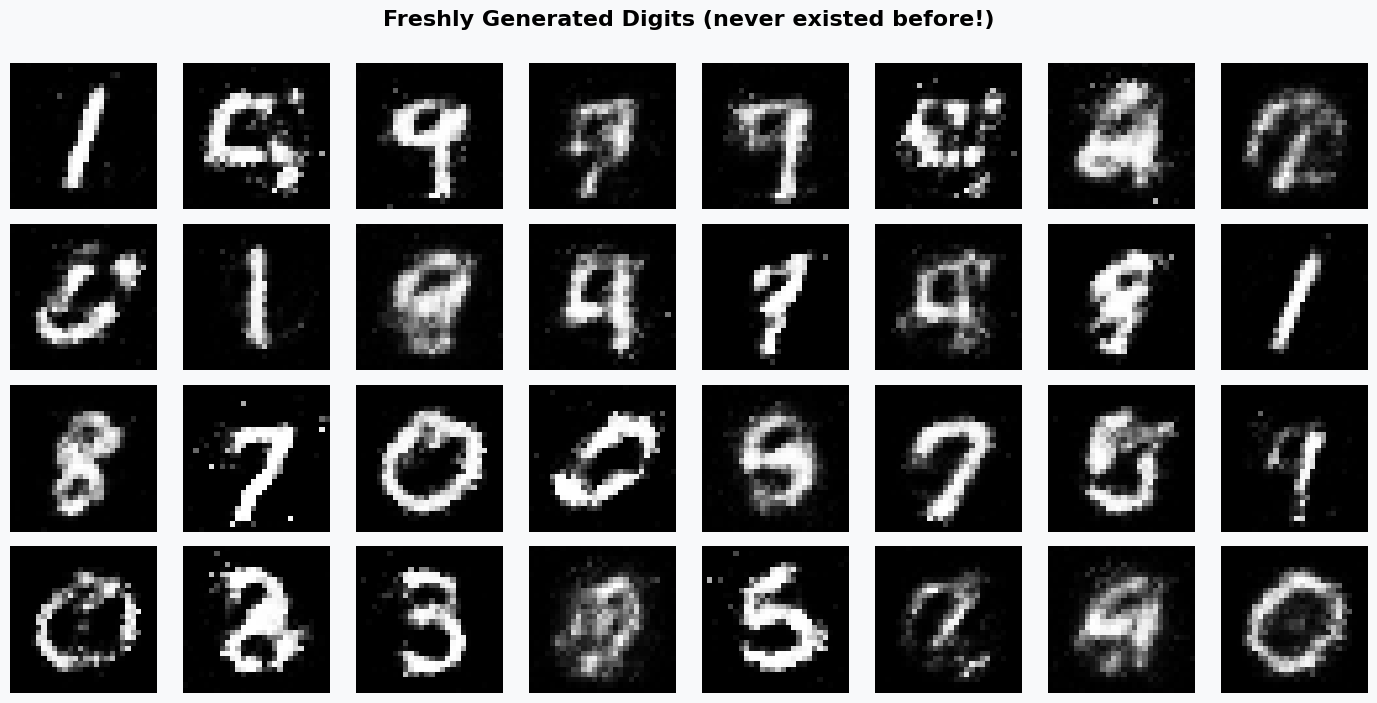

In [14]:
# Generate brand new digits!
G.eval()
n_new = 32
z_new = torch.from_numpy(np.random.uniform(-1, 1, size=(n_new, z_size))).float()
with torch.no_grad():
    generated = G(z_new)

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
fig.suptitle('Freshly Generated Digits (never existed before!)', fontsize=16, fontweight='bold', y=1.0)

for i, ax in enumerate(axes.flatten()):
    img = generated[i].detach().reshape(28, 28).numpy()
    ax.imshow(img, cmap='Greys_r')
    ax.axis('off')

plt.tight_layout()
plt.show()

---

# Training Summary Dashboard

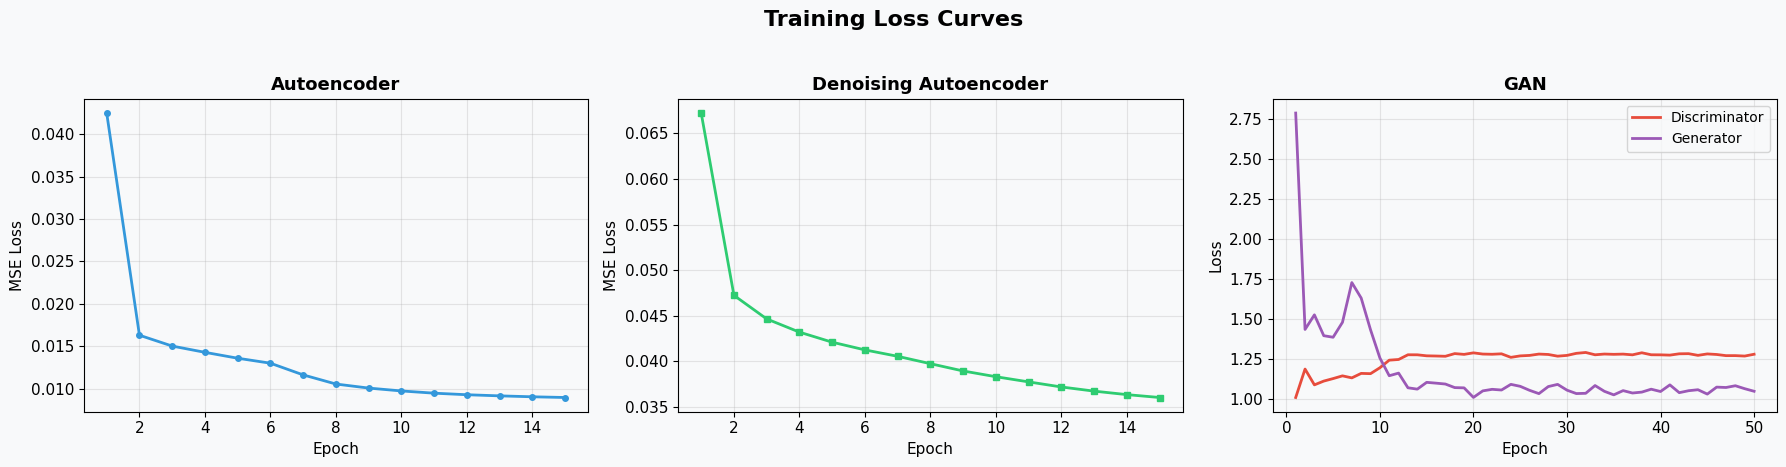

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
fig.suptitle('Training Loss Curves', fontsize=16, fontweight='bold', y=1.03)

# Autoencoder loss
axes[0].plot(range(1, len(ae_losses)+1), ae_losses, 'o-', color='#3498db', linewidth=2, markersize=4)
axes[0].set_title('Autoencoder', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].grid(True, alpha=0.3)

# Denoiser loss
axes[1].plot(range(1, len(dn_losses)+1), dn_losses, 's-', color='#2ecc71', linewidth=2, markersize=4)
axes[1].set_title('Denoising Autoencoder', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].grid(True, alpha=0.3)

# GAN losses
axes[2].plot(range(1, len(d_losses)+1), d_losses, '-', color='#e74c3c', linewidth=2, label='Discriminator')
axes[2].plot(range(1, len(g_losses)+1), g_losses, '-', color='#9b59b6', linewidth=2, label='Generator')
axes[2].set_title('GAN', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

# What Else Can You Explore?

This repository has many more deep learning techniques you can try:

| Module | Technique | Difficulty |
|--------|-----------|------------|
| `style-transfer/` | Transfer artistic style between images | Intermediate |
| `dcgan-svhn/` | Deep Convolutional GAN on street view house numbers | Intermediate |
| `cycle-gan/` | Transform photos between two domains (e.g. horse <-> zebra) | Advanced |
| `attention/` | Attention mechanisms for sequence models | Advanced |
| `transfer-learning/` | Use pre-trained networks (VGG) for new tasks | Beginner |
| `sentiment-rnn/` | Classify movie review sentiment with RNNs | Intermediate |
| `project-face-generation/` | Generate realistic human faces with DCGAN | Advanced |

Each directory contains Jupyter notebooks with exercises and solutions. Happy learning!